In [1]:
import os
import pandas as pd
import numpy as np
import lib
import shap

# Pré-requis : exécuter les notebooks précédents
file_path = './assets/sirh_normalized.csv'
df = None

if os.path.exists(file_path):
    df = pd.read_csv(file_path)
else:
    print(f"✗ Le fichier {file_path} n'existe pas")
    print("Assurez-vous d'avoir bien exécuté les notebooks précédents")

# Pré-requis : variable cible
target_var = 'a_quitte_l_entreprise'
random_state = 42

/usr/local/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Classification 
## Besoins métier

Dans notre cas métier, l’objectif est avant tout de **détecter les démissions potentielles**. Le jeu de données comporte environ 15% de salariés démissionnaires contre 85% restants, créant ainsi un déséquilibre naturel sur la variable cible `a_quitte_l_entreprise`. Dans ce contexte, il est préférable de **minimiser les faux négatifs** (salariés qui quittent mais que le modèle n’identifie pas), et de **favoriser la détection des vrais positifs** (départs correctement anticipés), même au prix de quelques faux positifs. Ci-dessous un résumé des différents cas possibles de notre modélisation.
                                            

| Cas                   | Prédiction | Réalité | Signification métier               |
|-----------------------|------------|---------|------------------------------------|
| **Vrai Positif (VP)** | Quitte     | Quitte  | Salarié à risque bien identifié    |
| **Vrai Négatif (VN)** | Reste      | Reste   | Salarié fidèle bien reconnu        |
| **Faux Positif (FP)** | Quitte     | Reste   | Salarié signalé à tort comme partant |
| **Faux Négatif (FN)** | Reste      | Quitte  | Salarié qui part mais non détecté  |



## Métriques clés

* **accuracy** n’est pas un bon indicateur ici ⚠️
  * Comme 85% des salariés restent, un modèle qui dit toujours “reste” aura déjà 85% d’accuracy, mais sera inutile pour détecter les démissions.
* **précision** : parmi ceux prédits comme démissionnaires, combien quittent vraiment ?
* **recall** : parmi tous ceux qui démissionnent vraiment, combien le modèle en détecte ?
  * Clé pour le métier : mieux vaut prévenir un départ qu’être surpris.
  * Si le recall est trop bas, l’entreprise continue à perdre beaucoup de talents sans anticipation.
  * (**recall faible = beaucoup de faux négatifs**)
* **F1-score** : c’est l’équilibre entre Précision et Recall.
  * Il est intéressant car il sanctionne quand on fait trop de faux positifs ou trop de faux négatifs.
  * Mais il reste un compromis : si l’entreprise veut absolument minimiser les départs non détectés (maximiser recall), alors le F1 n’est peut-être pas la seule métrique à viser.

**En résumé, on cherche à privilégier un bon recall, même s'il est au détriment de la précision**

In [2]:
# Variable cible
y = df[target_var]

# Features : toutes les autres colonnes
X = df.drop(target_var, axis=1)

## Classification : mode opératoire

### Modèle Dummy

Ce modèle va nous permettre de créer une base de comparaison des résultats de modélisation et de tirer des premières conclusions sur les valeurs des métriques.

### Validation croisée

Nous allons utiliser la validation croisée afin d'éviter l'overfitting des modèles.

### Déséquilibres de classes

Après plusieurs passes itératives sur les différents modèles, nous avons réalisé un aspect important de notre jeu de données. Comme nous avions dit plus haut avec **accuracy**, il y a un déséquilibre de classes entre les salariés qui quittent l'entreprise et ceux qui restent. Concrètement environ 15% des salariés quittent l'entreprise.
Cela signifie que lorsque nous allons entrainer nos différents modèles par validation croisée, chaque passe de aura un jeu de données avec une dispersion différente de salariés qui quittent l'entreprise. Cela influence le modèle.

#### Stratification
 our augmenter la précision de nos modèles nous allons procéder à une **stratification**. Cela permet de rééquilibrer la dispersion des salariés qui quittent l'entreprise pour chaque **fold** (passe)

## Modèle Dummy
### Implémentation


Précision du modèle Dummy (most_frequent) : 0.86
Rapport de classification (Dummy Most Frequent) :
              precision    recall  f1-score   support

       Reste       0.86      1.00      0.93       380
   Démission       0.00      0.00      0.00        61

    accuracy                           0.86       441
   macro avg       0.43      0.50      0.46       441
weighted avg       0.74      0.86      0.80       441



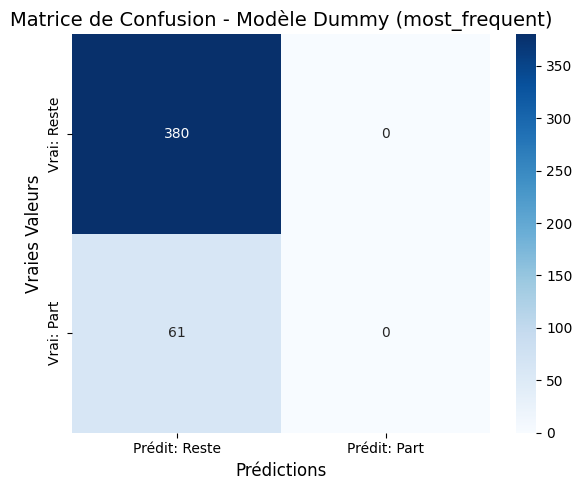


AUC-ROC du modèle Dummy : 0.50


In [3]:
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import seaborn as sns
import matplotlib.pyplot as plt

# Diviser les données en ensembles d'entraînement et de test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=random_state)

# Créer un modèle DummyClassifier
# Stratégie 'most_frequent' : prédit toujours la classe la plus fréquente
dummy_model = DummyClassifier(strategy='most_frequent')

# Entraîner le modèle (même si c'est un dummy, il a besoin d'être "fit" pour connaître la classe la plus fréquente)
dummy_model.fit(X_train, y_train)

# Faire des prédictions sur l'ensemble de test
y_pred_dummy = dummy_model.predict(X_test)

# Évaluer la performance du modèle dummy
accuracy_dummy = accuracy_score(y_test, y_pred_dummy)
print(f"Précision du modèle Dummy (most_frequent) : {accuracy_dummy:.2f}")

# Évaluation détaillée
print("Rapport de classification (Dummy Most Frequent) :")
print(classification_report(y_test, y_pred_dummy, target_names=["Reste", "Démission"], zero_division=0))

# Matrice de confusion
cm = confusion_matrix(y_test, y_pred_dummy, labels=[0,1])

# Création d'une matrice de confusion visuellement claire et simple
plt.figure(figsize=(6, 5))
sns.heatmap(cm, 
            annot=True, 
            fmt='d', 
            cmap='Blues',
            xticklabels=['Prédit: Reste', 'Prédit: Part'],
            yticklabels=['Vrai: Reste', 'Vrai: Part'])

plt.title('Matrice de Confusion - Modèle Dummy (most_frequent)', fontsize=14)
plt.xlabel('Prédictions', fontsize=12)
plt.ylabel('Vraies Valeurs', fontsize=12)

plt.tight_layout()
plt.show()

# AUC-ROC
# Attention : pour AUC il faut avoir predict_proba (proba de la classe 1)
y_proba_dummy = dummy_model.predict_proba(X_test)[:,1]  # probabilité d'attrition
auc_dummy = roc_auc_score(y_test, y_proba_dummy)
print(f"\nAUC-ROC du modèle Dummy : {auc_dummy:.2f}")

### Bilan
Notre modèle "Dummy" est aveugle au phénomène d'attrition, il n'a jamais prédit une seule démission.

* l'**AUC-ROC** du modèle dummy = 0.5 ce qui est tout à fait normal et représente bien le caractère aléatoire du modèle dummy
* **accuracy** est élevé (0.86), mais trompeuse car elle reflète juste le déséquilibre entrent les personnes qui restent et celles qui démissionnent (86%)

    * **Nous éviterons donc de nous baser sur cette métrique pour évaluer les performances de nos modèles**

Ce modèle de référence n’apporte pas d’information utile pour la détection de l’attrition.
Il constitue notre baseline minimale.
Nos modèles de machine learning doivent faire significativement mieux sur la classe "démission" (améliorer recall/F1 pour les départs), sinon ils ne sont pas exploitables pour les RH..


## Classification linéaire : régression logistique

Métrique,Moyenne,Écart-type
Accuracy,0.8796,0.0076
Precision,0.7377,0.0476
Recall,0.3965,0.0298
F1-score,0.5147,0.0298


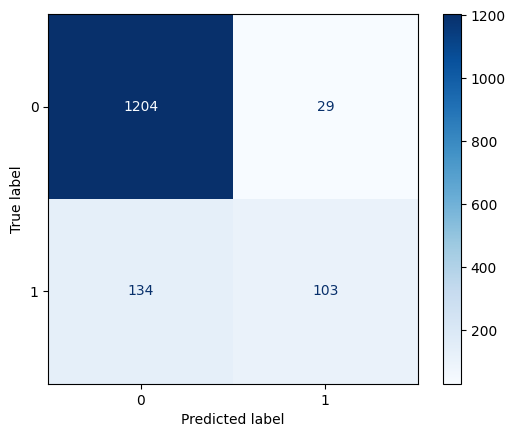

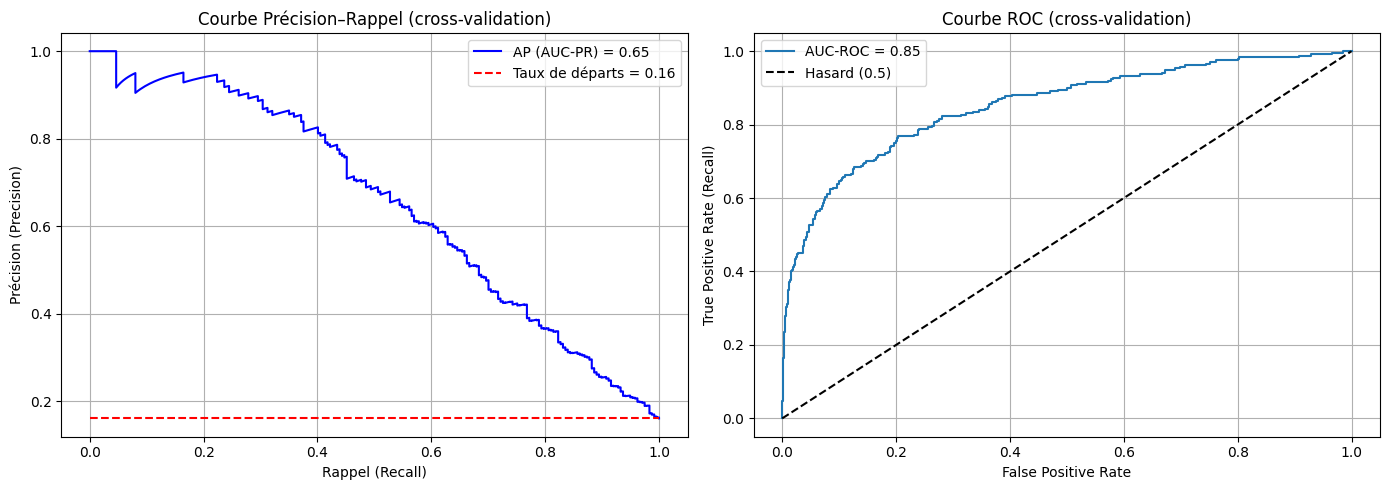

In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_validate, StratifiedKFold

# Modèle
clf = LogisticRegression(random_state=random_state, max_iter=1000)
cv_folds = 5

# Cross-validation
cv_results = cross_validate(
    clf, X, y,
    cv=StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=random_state),
    scoring=['accuracy', 'precision', 'recall', 'f1']
)

lib.display_cross_validate_results(cv_results)
lib.display_confusion_matrix(clf, X, y, cv_folds)
lib.display_pr_and_roc_curves(clf, X, y, cv_folds)

### Bilan 

* Le modèle obtient une accuracy de 0.886, ce qui signifie qu’il classe correctement près de 89% des salariés.
* La précision de 0.775 indique que lorsqu’il prédit une démission, il a raison environ 78% du temps.
* Le recall de 0.418 montre qu’il détecte un peu plus de 4 démissions sur 10.
* Enfin, le F1-score de 0.541 traduit un équilibre intermédiaire entre précision et recall, utile pour évaluer la qualité globale.

## Classification non-linéaire

### Random Forest

Métrique,Moyenne,Écart-type
Accuracy,0.8578,0.0223
Precision,0.5990,0.1138
Recall,0.4516,0.0571
F1-score,0.5070,0.0451


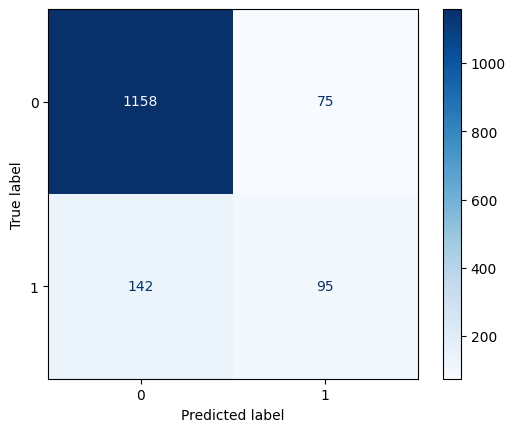

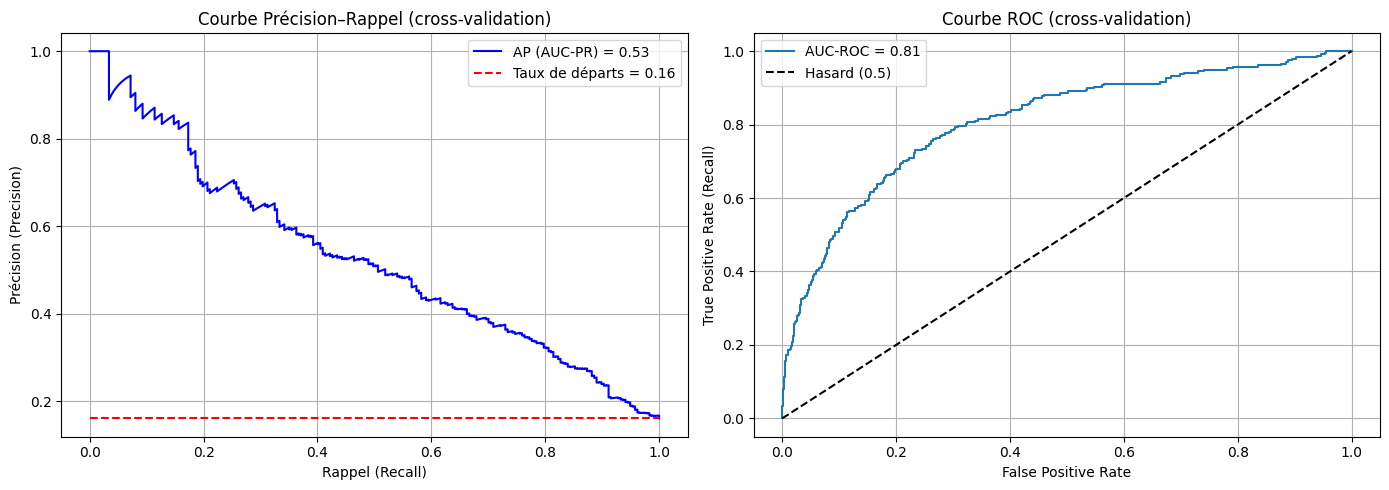

In [5]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import numpy as np

# Modèle RandomForest (non-linéaire)
rf_clf = RandomForestClassifier(
    n_estimators=500,
    max_depth=10,

    
    min_samples_split=5, # limite l'overfitting
    min_samples_leaf=5,
    class_weight="balanced_subsample", # permet de mieux gérer les déséquilibres de classes (démissionnent vs. ne démissionnent pas)
    
    random_state=random_state,
    n_jobs=-1
)

# Cross-validation avec plusieurs métriques
cv_results = cross_validate(
    rf_clf, X, y,
    cv=StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=random_state),
    scoring=["accuracy", "precision", "recall", "f1"],
    return_estimator=True  # pour récupérer les modèles entraînés
)

lib.display_cross_validate_results(cv_results)
lib.display_confusion_matrix(rf_clf, X, y, cv_folds)
lib.display_pr_and_roc_curves(rf_clf, X, y, cv_folds)


### XGBoost

**Remarque**: ici on utilise `scale_pos_weight` pour gérer le déséquilibre des classes entre les salariés qui démissionnent et ceux qui restent (env. 15% vs ~85%)

Métrique,Moyenne,Écart-type
Accuracy,0.8653,0.0276
Precision,0.6395,0.1532
Recall,0.4434,0.0605
F1-score,0.5177,0.0733


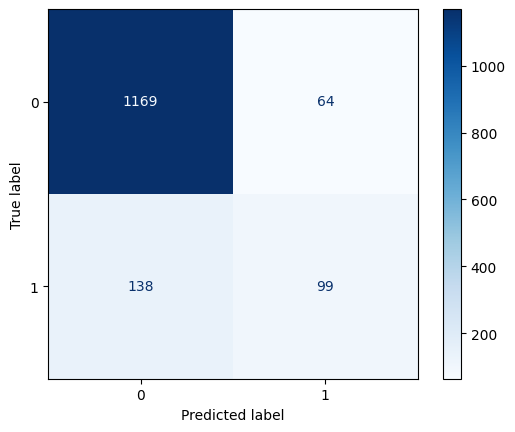

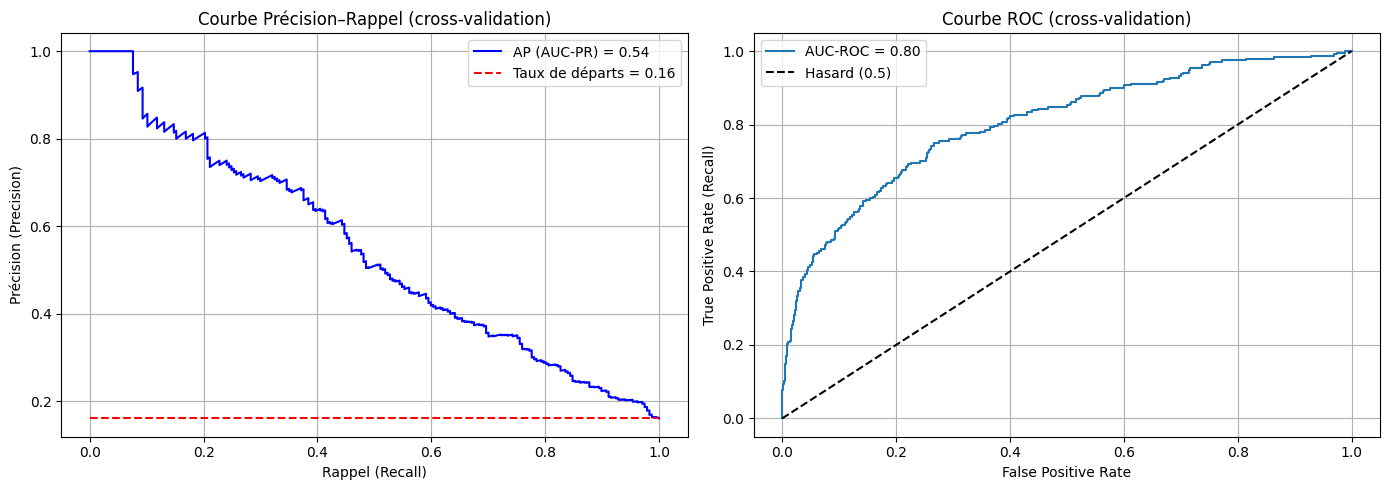

In [6]:
import xgboost as xgb

# /!\ Important : permet de gérer le déséquilibre (~15% de démissions contre ~85% qui restent)
scale_pos_weight = np.sum(y == 0) / np.sum(y == 1)

# Modèle XGBoost
xgb_clf = xgb.XGBClassifier(
    random_state=random_state,
    n_estimators=500,
    max_depth=10,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,  
    eval_metric='auc'  # Optimise sur AUC
)

# Cross-validation
cv_results = cross_validate(
    xgb_clf, X, y,
    cv = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=random_state),
    scoring=['accuracy', 'precision', 'recall', 'f1']
)

lib.display_cross_validate_results(cv_results)
lib.display_confusion_matrix(xgb_clf, X, y, cv_folds)
lib.display_pr_and_roc_curves(xgb_clf, X, y, cv_folds)

## Bilan des classifications
### Types de classification

En se basant principalement sur le F1-score, on se rend compte en premier lieu que dans l'état de notre analyse, les régressions linéaires et non-linéaires donnent à peu de choses près les mêmes performances..

Toutefois on peut remarquer que les **modèles non-linéaires sont un peu plus performants** sur le **recall** (ce qu'on cherche à améliorer dans notre cas)

* **On gardera donc un modèle non-linéaire**

### Courbes ROC

Pour les modèles non-linéaires, l’AUC-ROC est d’environ 0.8.
Cela signifie qu’en moyenne, dans 8 cas sur 10, le modèle attribue une probabilité de départ plus élevée à un salarié qui quitte réellement qu’à un salarié qui reste.
Autrement dit, **le modèle a une vraie capacité de discrimination entre les deux classes**.

**Remarque** : Comme l’AUC-ROC peut sembler optimiste en présence de classes déséquilibrées (ici seulement 16% de départs), nous avons également analysé la courbe Précision-Rappel, plus adaptée à ce contexte.

### Courbes Précision-rappel 

En se focalisant donc sur les modèles non-linéaires.
On se rend compte avec les premiers résultats que nous avons une moyenne de précision (**AP = PR-AUC**) correcte : 0.53, 0.54 (3 à 4 fois mieux que le hasard)
Comme 16% des salariés en moyenne quittent l'entreprise (dans notre jeu de données), un rendu aléatoire donnerait une précision de 0.16.

D'autre part on se rend compte que la précision diminue fortement en fonction du rappel, de manière assez linéaire.

On peut donc affirmer : 

* **Nos modèles apportent une vraie valeur ajoutée** car ils savent repérer les départs bien mieux que le hasard, **toutefois ils ne sont pas optimaux**.
* Plus on augmente la détection de salariés quittant l'entreprise, plus on perd en précision (augemente les faux positifs). C'est ce qu'on cherche mais jusqu'à un certain seuil

# Optimisation du modèle XGBoost

Nous avons choisi le modèle XGBoost qui donne les meilleurs résultats. Nous allons optimiser le modèle afin d'améliorer la performance.
Nous allons notamment rechercher sont les meilleurs hyperparamètres grâce à **GridSearchCV**.

## Recherche des meilleurs hyper-paramètres (GridSearchCV)

In [7]:
from sklearn.model_selection import GridSearchCV

# Paramètres à tester (à adapter selon tes besoins)
param_grid = {
    'n_estimators': [200, 500],
    'max_depth': [5, 8, 10],
    'learning_rate': [0.05, 0.1, 0.2],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

xgb_clf = xgb.XGBClassifier(
    random_state=random_state,
    scale_pos_weight=scale_pos_weight,
    eval_metric='auc'
)

grid_search = GridSearchCV(
    estimator=xgb_clf,
    param_grid=param_grid,
    scoring='f1',
    cv=StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=random_state),
    n_jobs=-1,
    verbose=0
)

grid_search.fit(X, y)

print("Meilleurs hyperparamètres :", grid_search.best_params_)
print("Meilleur score F1 (moyenne CV) :", grid_search.best_score_)

# ==== Modèle final ====
best_model = grid_search.best_estimator_

Meilleurs hyperparamètres : {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.8}
Meilleur score F1 (moyenne CV) : 0.5305693638620724


## Modèle optimisé

Métrique,Moyenne,Écart-type
Accuracy,0.8612,0.0201
Precision,0.5913,0.0724
Recall,0.4855,0.0578
F1-score,0.5306,0.0517


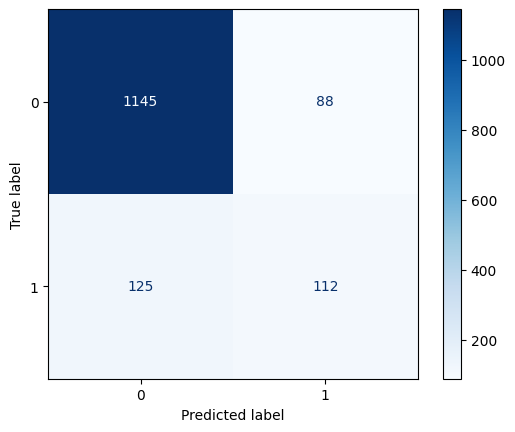

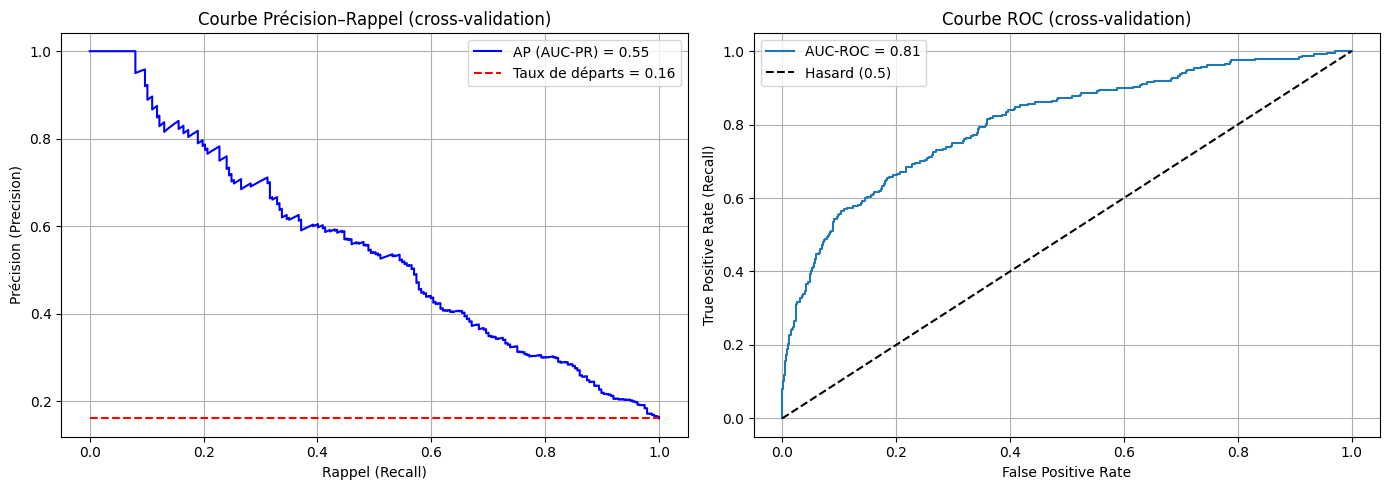

In [8]:
from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.metrics import make_scorer, f1_score, roc_auc_score

# Modèle optimisé trouvé par GridSearch
best_model = grid_search.best_estimator_

# Lancer une cross-validation classique avec F1, Recall, Precision, AUC
cv_results = cross_validate(
    best_model, X, y,
    cv=StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=random_state),
    scoring={
        'accuracy': 'accuracy',
        'f1': 'f1',
        'precision': 'precision',
        'recall': 'recall',
        'roc_auc': 'roc_auc'
    },
    return_estimator=False
)

lib.display_cross_validate_results(cv_results)
lib.display_confusion_matrix(best_model, X, y, cv_folds)
lib.display_pr_and_roc_curves(best_model, X, y, cv_folds)


## Feature importance globale (SHAP)

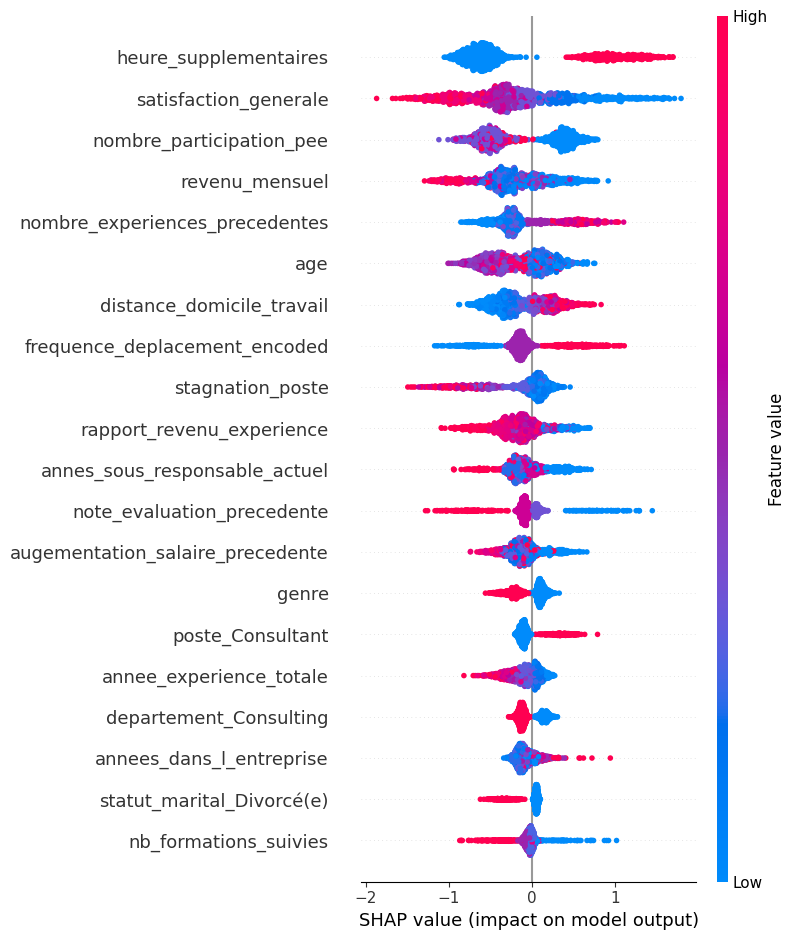

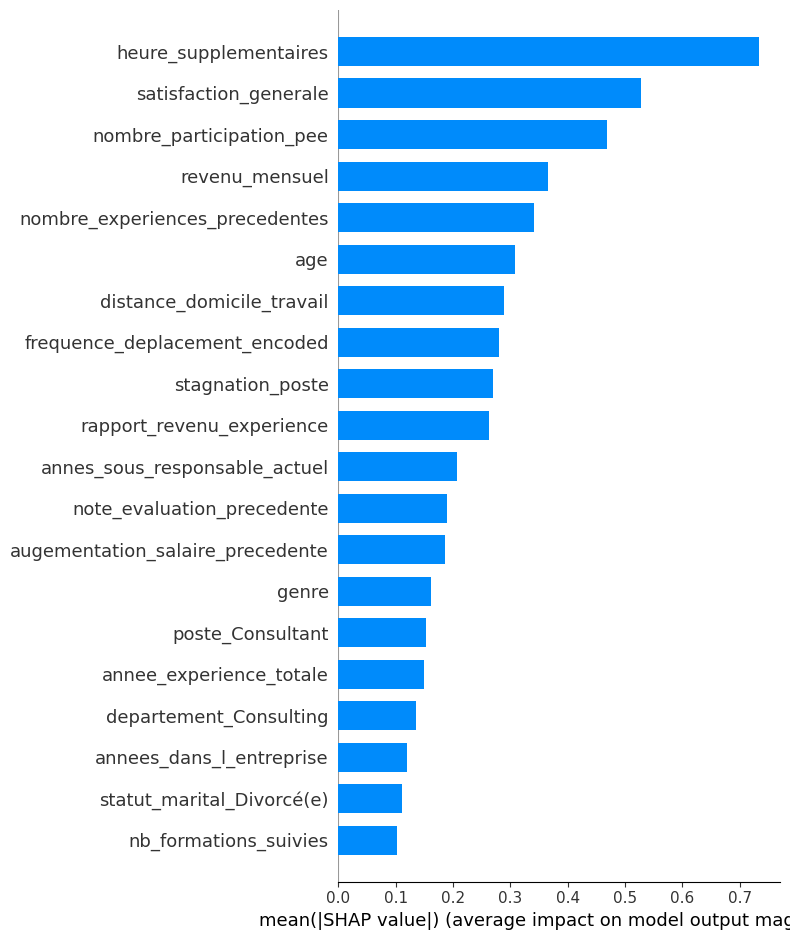

In [9]:
# Créer l'explainer SHAP (il est optimisé pour XGBoost)
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X)

shap.summary_plot(shap_values, X)  # nuage de points couleur = feature value
shap.summary_plot(shap_values, X, plot_type="bar")  # bar chart global importance

## Feature importance locale (SHAP)


Employé 720 - Vérité = 1, Proba départ prédite = 0.97


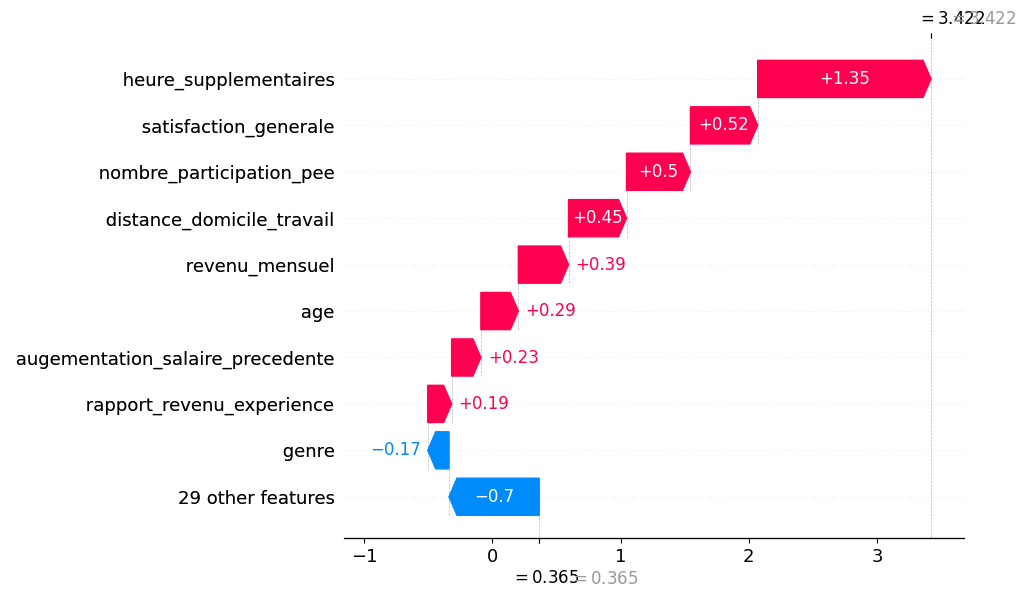


Employé 100 - Vérité = 1, Proba départ prédite = 0.92


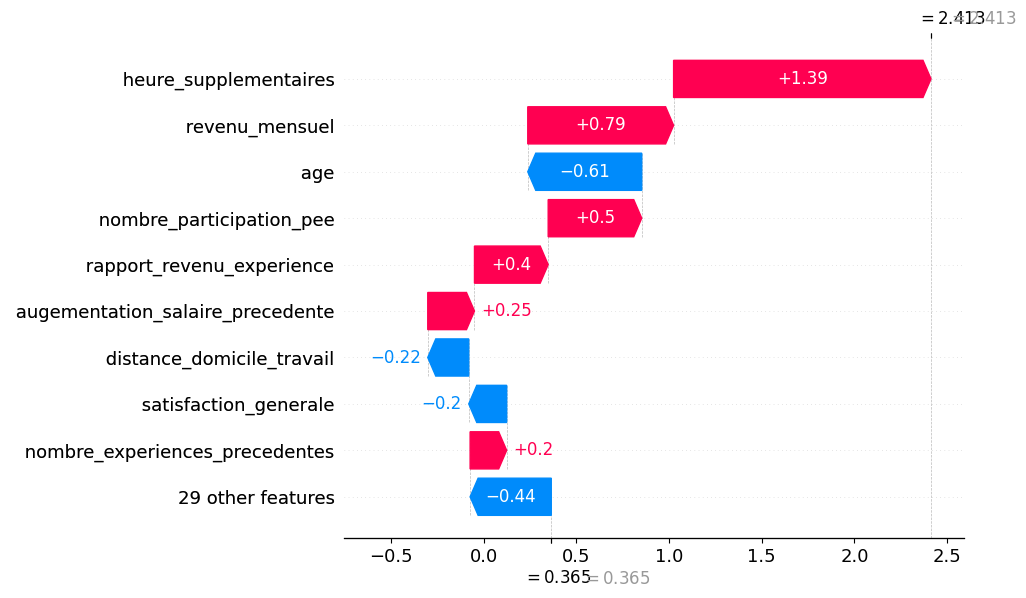


Employé 1281 - Vérité = 1, Proba départ prédite = 0.90


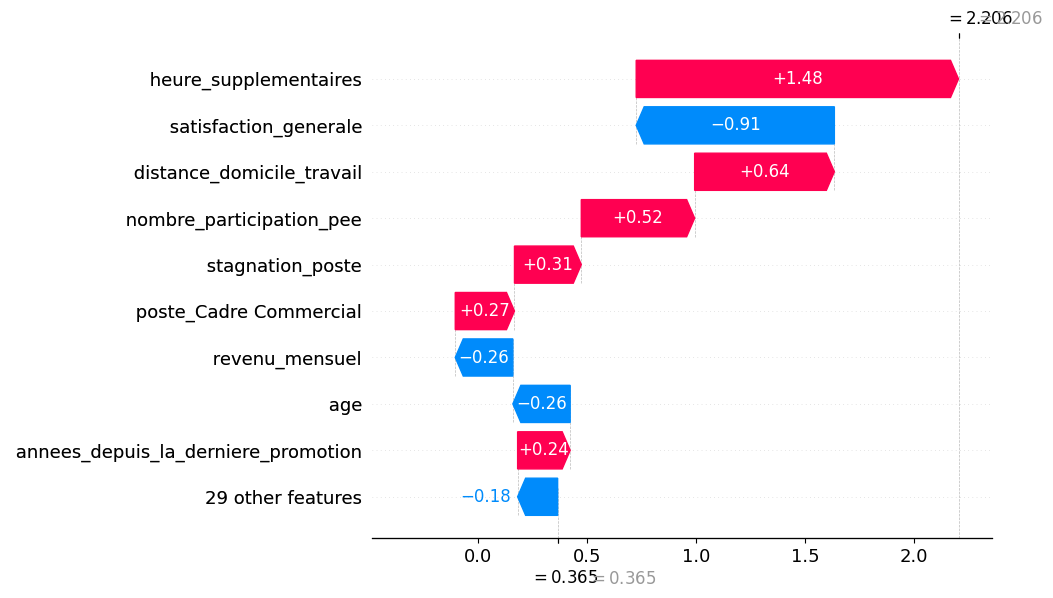


Employé 418 - Vérité = 0, Proba départ prédite = 0.06


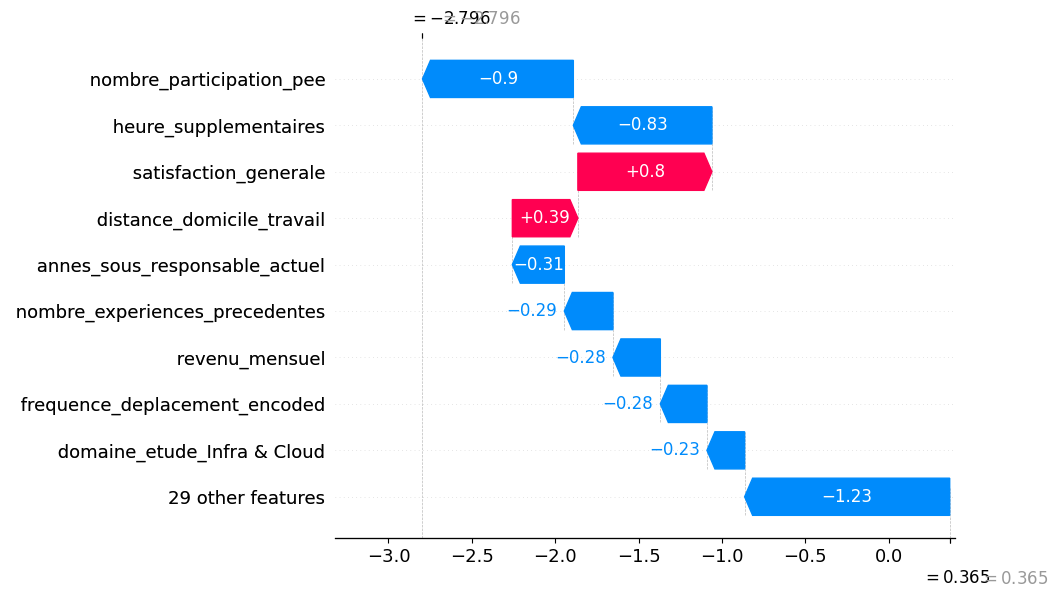


Employé 643 - Vérité = 0, Proba départ prédite = 0.03


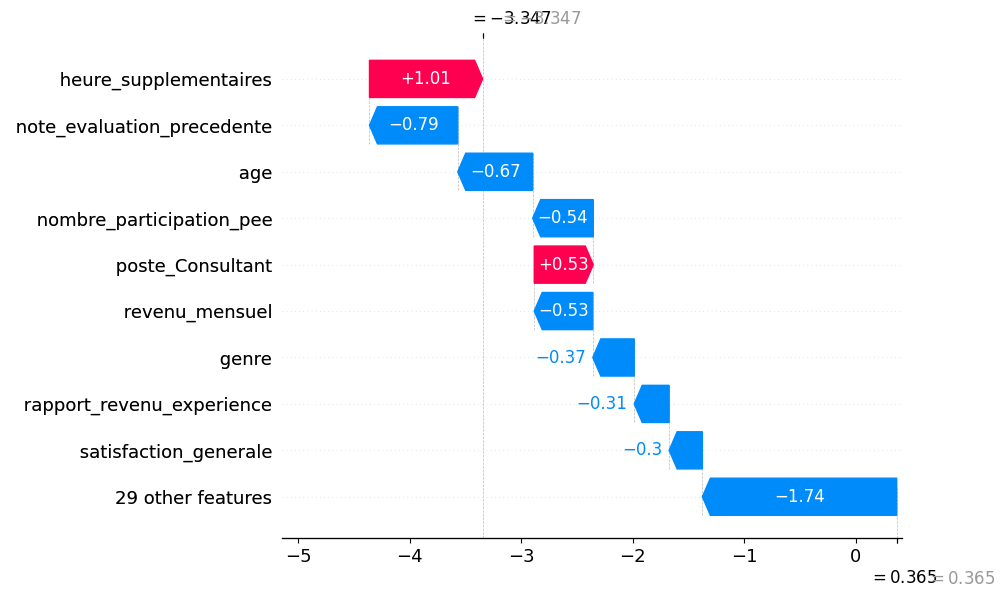


Employé 963 - Vérité = 0, Proba départ prédite = 0.01


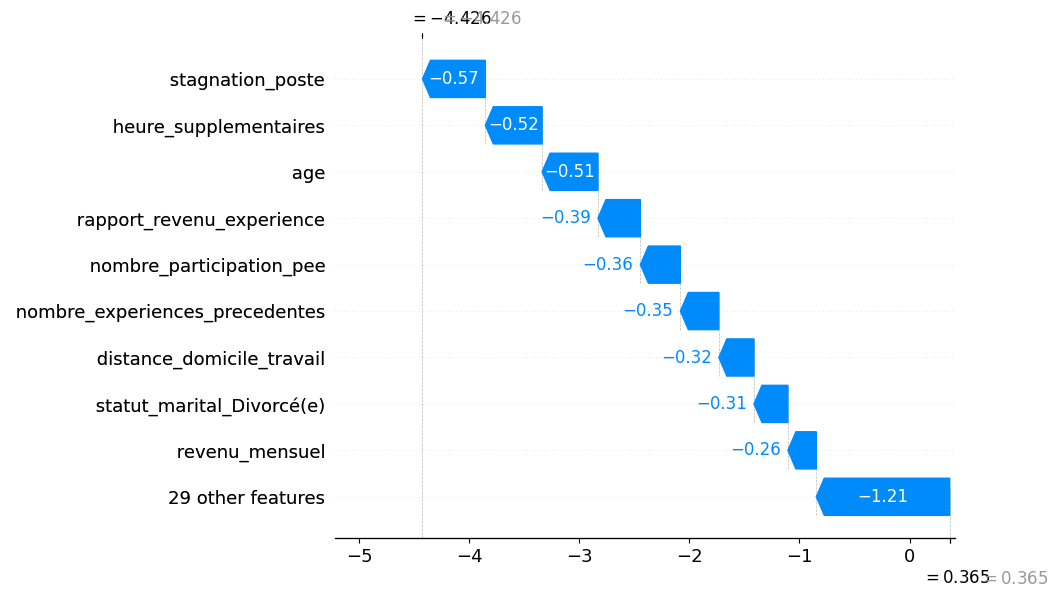

In [10]:


# Probabilités prédites
probas = best_model.predict_proba(X)[:, 1]  

# Indices des employés parti(e)s et resté(e)s
indices_depart = y[y == 1].sample(3, random_state=42).index   # 3 exemples aléatoires de départs
indices_reste = y[y == 0].sample(3, random_state=42).index    # 3 exemples aléatoires de non-départs

# Visualisation SHAP pour quelques cas
for idx in list(indices_depart) + list(indices_reste):
    print(f"\nEmployé {idx} - Vérité = {y.loc[idx]}, Proba départ prédite = {probas[idx]:.2f}")
    shap.force_plot(
        explainer.expected_value,
        shap_values[idx, :],
        X.iloc[idx, :]
    )
    
    # Vue locale "image fixe"
    shap.plots._waterfall.waterfall_legacy(
        explainer.expected_value, shap_values[idx, :], X.iloc[idx, :]
    )